In [1]:
!pip install -q -U adapters "transformers>=4.41.0" datasets optuna evaluate scikit-learn accelerate tqdm pandas huggingface_hub torch torchao torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130

In [4]:
import torch
import pandas as pd
import numpy as np
import optuna
import evaluate
from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, DefaultDataCollator
)
from adapters import (
    AdapterConfig,
    AdapterTrainer,
    setup_adapter_training
)
from huggingface_hub import HfApi
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import gc

In [5]:
SEED = 15179996
model_id = "mistralai/Mistral-7B-v0.3"
db_path = "sqlite:///adapter_study.db"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

In [6]:
def gpu_memory_gb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1024**3
    return 0

def compute_metrics(eval_pred):
    f1_metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels, average="weighted")

In [7]:
def prepare_dataset(dataset_name="bdanko/sentiment140", train_size=5000, test_size=1000):
    print(f"Loading dataset {dataset_name}...")
    dataset = load_dataset(dataset_name, split="train")
    df = dataset.to_pandas()

    # negative sentiment swapped to 1
    df['sentiment'] = df['sentiment'].replace(4, 1)

    train_df = df.sample(n=train_size, weights=df['sentiment'].map({0: 0.5, 1: 0.5}), random_state=SEED)
    remaining_df = df.drop(train_df.index)

    test_df_neg = remaining_df[remaining_df['sentiment'] == 0].sample(n=test_size // 2, random_state=SEED)
    test_df_pos = remaining_df[remaining_df['sentiment'] == 1].sample(n=test_size // 2, random_state=SEED)
    test_df = pd.concat([test_df_neg, test_df_pos]).sample(frac=1, random_state=SEED)

    return DatasetDict({
        "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
        "test": Dataset.from_pandas(test_df.reset_index(drop=True))
    })

In [8]:
dataset = prepare_dataset()
print(dataset)

Loading dataset bdanko/sentiment140...
DatasetDict({
    train: Dataset({
        features: ['text', 'date', 'user', 'sentiment', 'query'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['text', 'date', 'user', 'sentiment', 'query'],
        num_rows: 1000
    })
})


In [9]:
def tokenize_function(examples):
    texts = [f"Sentiment classification. Text: {text}\nSentiment: " for text in examples["text"]]
    tokenized = tokenizer(texts, truncation=True, max_length=128, padding="max_length")
    tokenized["labels"] = examples["sentiment"]
    return tokenized

tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [10]:
def get_base_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        num_labels=2,
        torch_dtype=torch.bfloat16,
        device_map={"": 0},
    )
    model.config.pad_token_id = model.config.eos_token_id
    from adapters import init
    init(model)
    return model

In [11]:
from adapters import BnConfig

def adapter_objective(trial):
    reduction_factor = trial.suggest_categorical("reduction_factor", [16, 32, 64])
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)

    adapter_config = BnConfig(
        mh_adapter=True,
        output_adapter=True,
        reduction_factor=reduction_factor,
        non_linearity="relu",
        dropout=dropout
    )

    torch.cuda.reset_peak_memory_stats()
    trial_model = get_base_model()

    adapter_name = "sentiment_adapter_trial"
    trial_model.add_adapter(adapter_name, config=adapter_config)
    trial_model.train_adapter(adapter_name)
    trial_model.set_active_adapters(adapter_name)

    training_args = TrainingArguments(
        output_dir="./adapter_results",
        per_device_train_batch_size=16,
        num_train_epochs=1,
        weight_decay=0.01,
        learning_rate=lr,
        eval_strategy="steps",
        eval_steps=50,
        logging_steps=50,
        bf16=True,
        report_to="none",
        save_strategy="no",
        disable_tqdm=True,
    )

    trainer = AdapterTrainer(
        model=trial_model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    trial.report(eval_results["eval_f1"], step=1)
    if trial.should_prune():
        del trainer, trial_model
        gc.collect()
        torch.cuda.empty_cache()
        raise optuna.exceptions.TrialPruned()

    trial.set_user_attr("peak_vram_gb", gpu_memory_gb())

    del trainer
    del trial_model
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    return eval_results["eval_f1"]

In [12]:
adapter_study = optuna.create_study(
    study_name="mistral_sentiment_adapter",
    storage=db_path,
    load_if_exists=True,
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
)

adapter_study.optimize(adapter_objective, n_trials=10)

[I 2026-04-25 22:22:38,179] Using an existing study with name 'mistral_sentiment_adapter' instead of creating a new one.


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

...

[I 2026-04-25 23:05:03,968] Trial 9 pruned. 


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some weights of MistralForSequenceClassification were not initialized from the model checkpoint at mistralai/Mistral-7B-v0.3 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'loss': 2.1752, 'grad_norm': 1278.47802734375, 'learning_rate': 1.5961086606699546e-05, 'epoch': 0.1597444089456869}
{'eval_loss': 1.916609287261963, 'eval_f1': 0.4830818035690622, 'eval_runtime': 12.3188, 'eval_samples_per_second': 81.177, 'eval_steps_per_second': 10.147, 'epoch': 0.1597444089456869}
{'loss': 1.5782, 'grad_norm': 1292.15283203125, 'learning_rate': 1.2938153537248876e-05, 'epoch': 0.3194888178913738}
{'eval_loss': 1.1620856523513794, 'eval_f1': 0.5010526571988366, 'eval_runtime': 12.3524, 'eval_samples_per_second': 80.956, 'eval_steps_per_second': 10.12, 'epoch': 0.3194888178913738}
{'loss': 1.1137, 'grad_norm': 1394.487548828125, 'learning_rate': 9.915220467798203e-06, 'epoch': 0.4792332268370607}
{'eval_loss': 1.0163511037826538, 'eval_f1': 0.4693743858499837, 'eval_runtime': 12.3364, 'eval_samples_per_second': 81.061, 'eval_steps_per_second': 10.133, 'epoch': 0.4792332268370607}
{'loss': 1.0753, 'grad_norm': 532.1641845703125, 'learning_rate': 6.892287398347532e-06

[I 2026-04-25 23:09:40,161] Trial 10 finished with value: 0.5164663235733447 and parameters: {'reduction_factor': 64, 'dropout': 0.029485732411583063, 'lr': 1.8923561014761205e-05}. Best is trial 8 with value: 0.5736657539510978.


In [13]:
def summarize_study(study_name, method_label):
    try:
        study = optuna.load_study(study_name=study_name, storage=db_path)
        df = study.trials_dataframe()
        df = df[df['state'] == 'COMPLETE'].copy()
        if 'user_attrs_peak_vram_gb' in df.columns:
            df['peak_vram_gb'] = df['user_attrs_peak_vram_gb']

        print(f"\n### Summary for {method_label} ({study_name}) ###")
        print(f"Best Trial F1: {study.best_value:.4f}")
        print(f"Best Parameters: {study.best_params}")

        cols_to_show = [col for col in df.columns if col.startswith('params_') or col in ['value', 'peak_vram_gb']]
        return df[cols_to_show].sort_values(by='value', ascending=False)
    except Exception as e:
        return f"Could not load {study_name}: {e}"

adapter_summary = summarize_study("mistral_sentiment_adapter", "Adapters")
display(adapter_summary.head())


### Summary for Adapters (mistral_sentiment_adapter) ###
Best Trial F1: 0.5737
Best Parameters: {'reduction_factor': 16, 'dropout': 0.17640177247960154, 'lr': 0.00025773023366483446}


,value,params_dropout,params_lr,params_reduction_factor,peak_vram_gb
8,0.573666,0.176402,0.000258,16,26.123433
5,0.531293,0.293421,0.000011,64,24.763966
10,0.516466,0.029486,0.000019,64,24.763966
4,0.465496,0.207065,0.000124,32,25.217091
3,0.339675,0.000393,0.000021,64,24.763966


In [16]:
def train_best_adapter(study):
    best_params = study.best_params

    adapter_config = BnConfig(
        mh_adapter=True,
        output_adapter=True,
        reduction_factor=best_params['reduction_factor'],
        non_linearity="relu",
        dropout=best_params['dropout']
    )

    lr = best_params['lr']
    out_dir = "./best_adapter"
    hub_id = "bdanko/mistral-7b-sentiment-adapter"

    torch.cuda.reset_peak_memory_stats()
    model = get_base_model()

    adapter_name = "best_sentiment_adapter"
    model.add_adapter(adapter_name, config=adapter_config)
    model.train_adapter(adapter_name)
    model.set_active_adapters(adapter_name)

    args = TrainingArguments(
        output_dir=out_dir,
        per_device_train_batch_size=16,
        num_train_epochs=5,
        learning_rate=lr,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=False,
        metric_for_best_model="f1",
        bf16=True,
        report_to="none",
        push_to_hub=True,
        hub_model_id=hub_id,
    )

    trainer = AdapterTrainer(
        model=model,
        args=args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        compute_metrics=compute_metrics,
    )

    trainer.train()
    trainer.model.save_pretrained(out_dir)

    final_metrics = trainer.evaluate()
    peak_vram = gpu_memory_gb()
    return trainer, final_metrics, peak_vram

In [17]:
adapter_study = optuna.load_study(study_name="mistral_sentiment_adapter", storage=db_path)
best_adapter_trainer, best_adapter_metrics, adapter_vram = train_best_adapter(adapter_study)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some weights of MistralForSequenceClassification were not initialized from the model checkpoint at mistralai/Mistral-7B-v0.3 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1
1,No log,0.776354,0.333333
2,1.373900,0.688293,0.523621
3,1.373900,0.820521,0.333333
4,0.896900,0.678725,0.578648
5,0.715600,0.654689,0.640000


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


In [18]:
best_adapter_metrics

{'eval_loss': 0.6546894311904907,
 'eval_f1': 0.64,
 'eval_runtime': 12.6461,
 'eval_samples_per_second': 79.076,
 'eval_steps_per_second': 9.884,
 'epoch': 5.0}

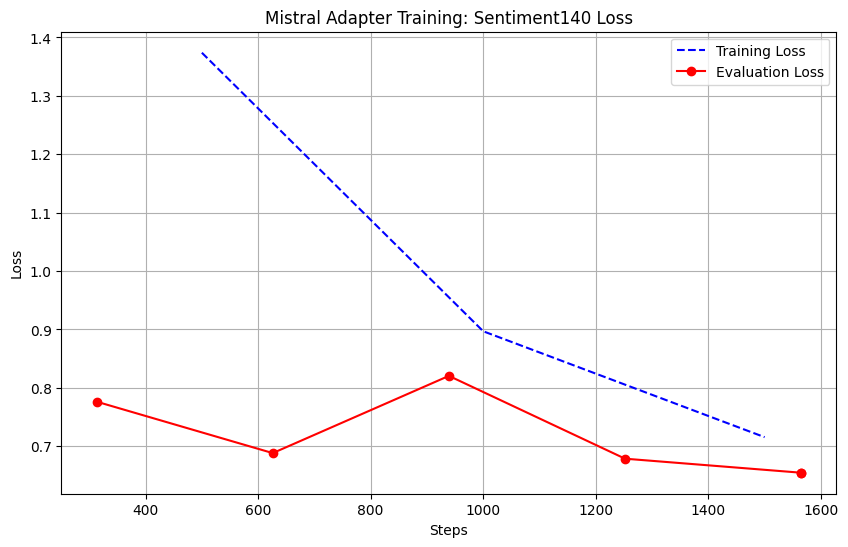

In [22]:
import matplotlib.pyplot as plt

history = best_adapter_trainer.state.log_history

train_loss = [log["loss"] for log in history if "loss" in log]
train_steps = [log["step"] for log in history if "loss" in log]

eval_loss = [log["eval_loss"] for log in history if "eval_loss" in log]
eval_steps = [log["step"] for log in history if "eval_loss" in log]

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color='blue', linestyle='--')
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Evaluation Loss", color='red', marker='o')

plt.title("Mistral Adapter Training: Sentiment140 Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
import torch
from transformers import AutoModelForSequenceClassification
from adapters import init

model_id = "mistralai/Mistral-7B-v0.3"
adapter_folder_path = "./best_adapter/checkpoint-1565/best_sentiment_adapter"
adapter_name = "best_sentiment_adapter"

model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=2,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},
)

model.config.pad_token_id = model.config.eos_token_id

init(model)

print(f"Loading adapter from {adapter_folder_path}...")
model.load_adapter(adapter_folder_path)
model.set_active_adapters(adapter_name)

print("Model and Adapter loaded successfully with padding defined.")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some weights of MistralForSequenceClassification were not initialized from the model checkpoint at mistralai/Mistral-7B-v0.3 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading adapter from ./best_adapter/checkpoint-1565/best_sentiment_adapter...


Model and Adapter loaded successfully with padding defined.


In [16]:
import evaluate
import numpy as np
from adapters import AdapterTrainer
from transformers import TrainingArguments


def compute_all_metrics(eval_pred):
    metrics = {
        "accuracy": evaluate.load("accuracy"),
        "precision": evaluate.load("precision"),
        "recall": evaluate.load("recall"),
        "f1": evaluate.load("f1")
    }

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": metrics["accuracy"].compute(predictions=predictions, references=labels)["accuracy"],
        "precision": metrics["precision"].compute(predictions=predictions, references=labels)["precision"],
        "recall": metrics["recall"].compute(predictions=predictions, references=labels)["recall"],
        "f1": metrics["f1"].compute(predictions=predictions, references=labels)["f1"]
    }

eval_args = TrainingArguments(
    output_dir="./eval_results",
    bf16=True,
    per_device_eval_batch_size=16,
    remove_unused_columns=False
)

eval_trainer = AdapterTrainer(
    model=model,
    args=eval_args,
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_all_metrics,
)

print("Calculating metrics...")
results = eval_trainer.evaluate()
print(f"\nFinal Metrics:\n{results}")

Calculating metrics...


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin



Final Metrics:
{'eval_loss': 0.6552602648735046, 'eval_model_preparation_time': 0.0132, 'eval_accuracy': 0.639, 'eval_precision': 0.6387225548902196, 'eval_recall': 0.64, 'eval_f1': 0.6393606393606394, 'eval_runtime': 14.063, 'eval_samples_per_second': 71.108, 'eval_steps_per_second': 4.48}
